In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import torch
import CustomModules.CAE_Utils as CAE_Utils
from datasets import load_dataset
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [5]:
from torch.utils.data import Dataset
from torchvision import datasets

In [62]:
mnist = datasets.MNIST(root='data', train=True, download=True, transform=None)
mnist_test = datasets.MNIST(root='data', train=False, download=True, transform=None)

In [78]:

X_data = mnist.data.float()
X_data_test = mnist_test.data.float()

X_data = X_data / 255.0
X_data_test = X_data_test / 255.0

X_data = X_data.reshape(-1, 28*28)
X_data_test = X_data_test.reshape(-1, 28*28)

X_loader = torch.utils.data.DataLoader(X_data, batch_size=1024, shuffle=True)
X_loader_test = torch.utils.data.DataLoader(X_data_test, batch_size=1024, shuffle=False)

In [106]:
cae = CAE_Utils.CAE(784, 32, 10, 128, 128, 10, 5)
CAE_Utils.train_cae(epochs=30, x_train_loader=X_loader, network=cae, device=device)

100%|██████████| 30/30 [00:30<00:00,  1.01s/it]


In [115]:
cae.to("cpu")
batch = next(iter(X_loader_test))[0:10]
reconstructed = cae.encode_decode(batch).detach().numpy()



In [113]:
cae.to("cpu")
batch = next(iter(X_loader_test))[0:10]
reconstructed = cae.decode(cae.encode(batch)).detach().numpy()

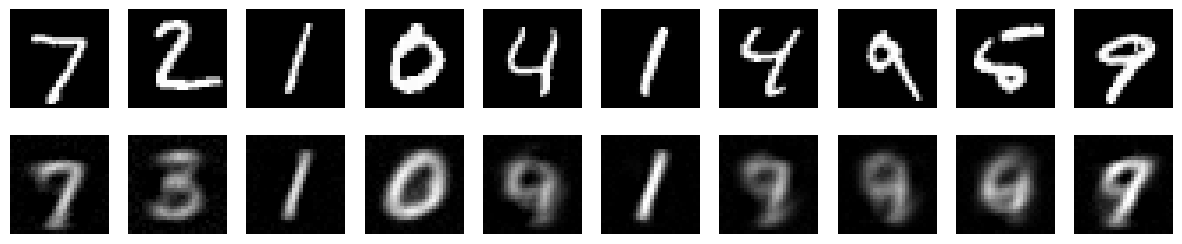

In [116]:

#plot both batch and reconstructed images
fig, axs = plt.subplots(2, 10, figsize=(15, 3))

for i, (image, ax) in enumerate(zip(batch, axs[0])):
    ax.imshow(image.reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")

for i, (image, ax) in enumerate(zip(reconstructed, axs[1])):
    ax.imshow(image.reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")

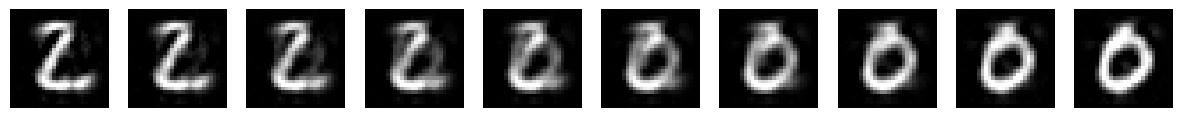

In [ ]:


start_encoded = cae.encode(batch[1].unsqueeze(0))
end_encoded = cae.encode(batch[3].unsqueeze(0))
interpolated = torch.linspace(0, 1, steps=10).unsqueeze(1) * end_encoded + (1 - torch.linspace(0, 1, steps=10).unsqueeze(1)) * start_encoded
decoded_interpolated = cae.decode(interpolated).detach().numpy()
#plot
fig, axs = plt.subplots(1, 10, figsize=(15, 3))
for i, (image, ax) in enumerate(zip(decoded_interpolated, axs)):
    ax.imshow(image.reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")



In [74]:

from CustomModules.util import farthest_point_sample


points = torch.randn(500, 3)

sampled, idx = farthest_point_sample(points, 3)

print(sampled)
print(idx)

tensor([[ 0.5647,  1.7357, -0.9725],
        [-3.9658,  0.8347,  2.0148],
        [ 0.3041, -2.4347,  1.4950]])
tensor([  0, 293, 299])
